# 실습 3-2 : GBM, XGBoost, LightGBM, CatBoost

#### **<실습 내용>**

1. 분류 (Classification) - MachineFailure 데이터
- GBM, XGBoost, LightGBM, CatBoost 모델 학습 및 하이퍼 파라미터 최적화
- 모델 결과 비교 

2. 회귀 (Regression) - Concrete 데이터
- GBM, XGBoost, LightGBM, CatBoost 모델 학습 및 하이퍼 파라미터 최적화
- 모델 결과 비교 

## 분석 준비

### 주요 라이브러리 호출

In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ===== 한글 폰트 설정 =====
FONT_CANDIDATES = [
    "/System/Library/Fonts/AppleSDGothicNeo.ttc",
    "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
    "C:/Windows/Fonts/malgun.ttf",
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
]
FONT_PATH = next((p for p in FONT_CANDIDATES if os.path.exists(p)), None)
if FONT_PATH:
    fm.fontManager.addfont(FONT_PATH)
    KOREAN_FONT = fm.FontProperties(fname=FONT_PATH)
    rcParams["font.family"] = KOREAN_FONT.get_name()
else:
    KOREAN_FONT = None

rcParams["axes.unicode_minus"] = False

### 성능 평가 함수 정의

In [3]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))

# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

---

## 1. 분류 (Classification) - MachineFailure 데이터

### 데이터 전처리

In [4]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-2_cls_data.csv"))

# 입출력 변수 분할 및 전처리
Y = MF_Data["Failure"]
X = MF_Data.drop(["Failure"], axis=1)

X["Measure2"] = X["Measure2"].astype("category")
X["Measure3"] = X["Measure3"].astype("category")
X = pd.get_dummies(X)
data_columns = X.columns

Y = Y.replace({"No": 0, "Yes": 1})

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0, stratify=Y)
print("학습 데이터 :", X_train.shape)
print("테스트 데이터 :", X_test.shape)

학습 데이터 : (5530, 31)
테스트 데이터 : (2370, 31)


/var/folders/pz/g1s7yv693t5ddnqs0qzvsqvr0000gn/T/ipykernel_9123/4124609564.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = Y.replace({"No": 0, "Yes": 1})


---

### 1-1) GBM

> **GBM (Gradient Boosting Machine)** 은 이전 라운드의 베이스 모델이 잘못 예측한 **잔차(residual)** 를 다음 라운드의 베이스 모델이 학습하는 순차적 앙상블 기법임

In [5]:
GBM_cls = GradientBoostingClassifier()
GBM_cls.fit(X_train, Y_train)
GBM_cls_pred = GBM_cls.predict(X_test)
get_classscore(Y_test, GBM_cls_pred)

Accuracy  : 0.997
Precision : 0.944
Recall    : 0.773
F1-score  : 0.850


#### 변수 중요도 시각화

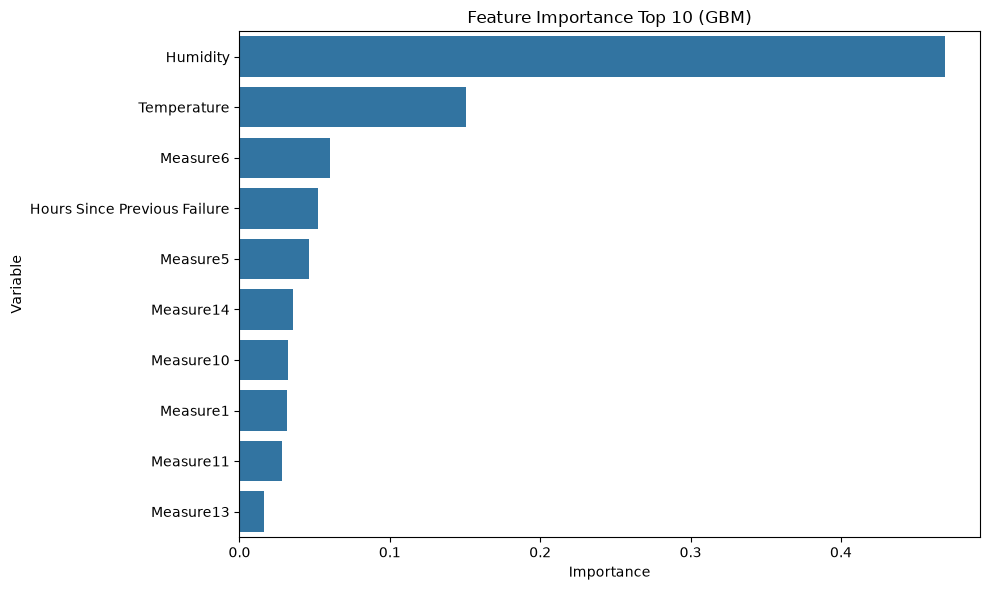

In [6]:
var_imp_gbm_cls = pd.DataFrame({"Variable": X_train.columns, "Importance": GBM_cls.feature_importances_})
imp_top10_gbm_cls = var_imp_gbm_cls.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10_gbm_cls)
plt.title("Feature Importance Top 10 (GBM)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

> GBM의 주요 하이퍼 파라미터:
>
> | 하이퍼파라미터 | 기본값 | 하이퍼파라미터 설명 |
> |:---:|:---:|:---:|
> | learning_rate | 0.1 | 이전 오차를 얼마나 반영할지 결정 |
> | subsample | 1.0 | 각 트리 학습 시 사용할 데이터 비율 |
> | validation_fraction | 0.1 | 조기 종료를 위한 검증 데이터 비율 |
> | n_iter_no_change | None | 성능 향상이 없을 경우 학습 중단 |
> | n_estimators | 100 | 생성할 트리의 개수 |
> | max_depth | 3 | 트리의 최대 깊이 |
> | max_leaf_nodes | None | 리프 노드의 최대 개수 |
> | min_samples_leaf | 1 | 리프 노드가 되기 위한 최소 샘플 수 |
> | min_samples_split | 2 | 노드를 분할하기 위한 최소 샘플 수 |

In [7]:
params_gbm_cls = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_leaf": [1, 5],
    "subsample": [0.8, 1.0]
}

grid_gbm_cls = GridSearchCV(
    GradientBoostingClassifier(random_state=0),
    param_grid=params_gbm_cls, cv=3, scoring="f1", n_jobs=-1
)
grid_gbm_cls.fit(X_train, Y_train)

print("최적 파라미터:", grid_gbm_cls.best_params_)
print("최적 F1-score (CV): %.4f" % grid_gbm_cls.best_score_)

최적 파라미터: {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 300, 'subsample': 0.8}
최적 F1-score (CV): 0.8291


In [8]:
best_gbm_cls_pred = grid_gbm_cls.predict(X_test)
print("[GBM - 최적 모델]")
get_classscore(Y_test, best_gbm_cls_pred)

[GBM - 최적 모델]
Accuracy  : 0.997
Precision : 0.944
Recall    : 0.773
F1-score  : 0.850


---

### 1-2) XGBoost

> **XGBoost**는 GBM에 **트리 규제항(Regularization)** 을 추가하여 과적합을 방지하는 모델임

In [9]:
XGB_cls = XGBClassifier()
XGB_cls.fit(X_train, Y_train)
XGB_cls_pred = XGB_cls.predict(X_test)
get_classscore(Y_test, XGB_cls_pred)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.682
F1-score  : 0.811


#### 변수 중요도 시각화

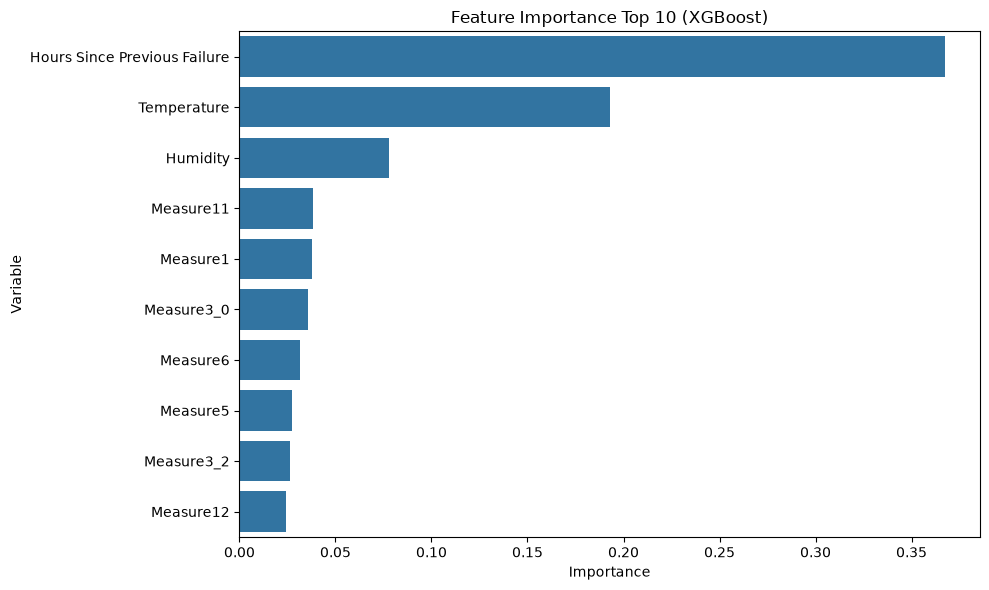

In [10]:
var_imp_xgb_cls = pd.DataFrame({"Variable": X_train.columns, "Importance": XGB_cls.feature_importances_})
imp_top10_xgb_cls = var_imp_xgb_cls.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10_xgb_cls)
plt.title("Feature Importance Top 10 (XGBoost)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

> XGBoost의 주요 하이퍼 파라미터:
>
> | 하이퍼파라미터 | 기본값 | 하이퍼파라미터 설명 |
> |:---:|:---:|:---:|
> | colsample_bytree | 1.0 | 각 트리 학습 시 사용할 변수 비율 |
> | gamma | 0.0 | 추가 분할을 수행할 최소 기준 값 (클수록 단순한 모델 생성) |
> | reg_lambda | 1.0 | 과적합 방지를 위한 정규화 강도 |
> | n_estimators | 100 | 생성할 트리의 개수 |
> | max_depth | 6 | 트리의 최대 깊이 |
> | learning_rate | 0.1 | 각 트리가 이전 오차를 얼마나 반영할지 결정 |

In [11]:
params_xgb_cls = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "gamma": [0, 2],
    "reg_lambda": [1, 5],
    "subsample": [0.8, 1.0]
}

grid_xgb_cls = GridSearchCV(
    XGBClassifier(random_state=0, eval_metric="logloss"),
    param_grid=params_xgb_cls, cv=3, scoring="f1", n_jobs=-1
)
grid_xgb_cls.fit(X_train, Y_train)

print("최적 파라미터:", grid_xgb_cls.best_params_)
print("최적 F1-score (CV): %.4f" % grid_xgb_cls.best_score_)

최적 파라미터: {'gamma': 0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'reg_lambda': 1, 'subsample': 1.0}
최적 F1-score (CV): 0.8335


In [12]:
best_xgb_cls_pred = grid_xgb_cls.predict(X_test)
print("[XGBoost - 최적 모델]")
get_classscore(Y_test, best_xgb_cls_pred)

[XGBoost - 최적 모델]
Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842


---

### 1-3) LightGBM

> **LightGBM**은 GBM의 학습 속도를 개선한 모델로, 다음 기술을 사용함
> - **GOSS** (Gradient-Based One Side Sampling): 잔차가 큰 데이터를 우선 학습하여 학습 데이터를 줄임
> - **Leaf-Wise Tree Growth**: 가장 큰 Loss를 가진 노드만 분할하여 트리 생성 속도를 높임
> - XGBoost 대비 최대 **38배 빠른 학습 속도**를 보이면서 비슷하거나 높은 정확도를 달성함

In [13]:
LGBM_cls = LGBMClassifier(verbose=-1)
LGBM_cls.fit(X_train, Y_train)
LGBM_cls_pred = LGBM_cls.predict(X_test)
get_classscore(Y_test, LGBM_cls_pred)

Accuracy  : 0.998
Precision : 1.000
Recall    : 0.773
F1-score  : 0.872


#### 변수 중요도 시각화

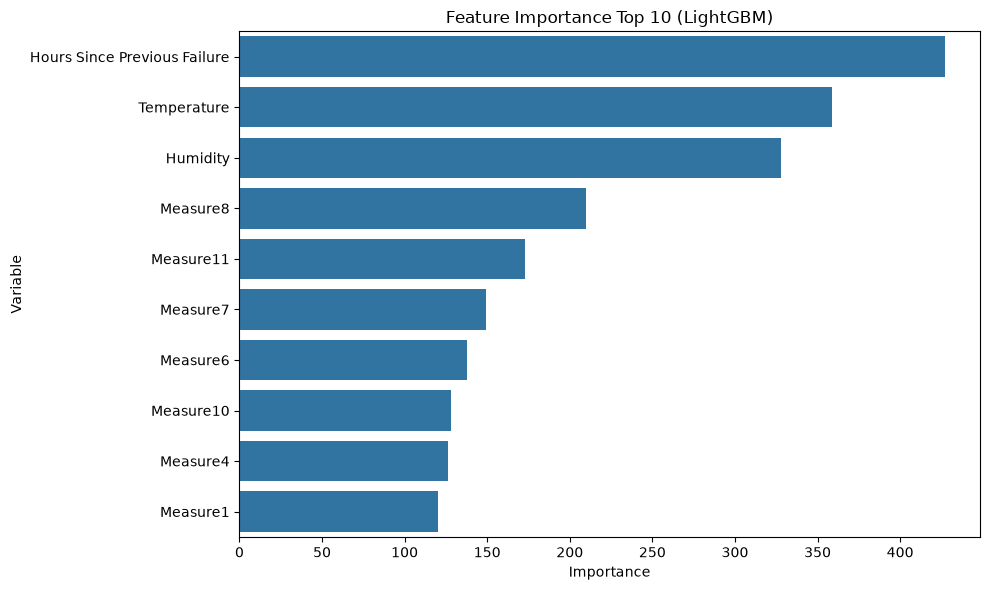

In [14]:
var_imp_lgbm_cls = pd.DataFrame({"Variable": X_train.columns, "Importance": LGBM_cls.feature_importances_})
imp_top10_lgbm_cls = var_imp_lgbm_cls.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10_lgbm_cls)
plt.title("Feature Importance Top 10 (LightGBM)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

> LightGBM의 주요 하이퍼 파라미터:
>
> | 하이퍼파라미터 | 기본값 | 하이퍼파라미터 설명 |
> |:---:|:---:|:---:|
> | num_leaves | 31 | 하나의 트리가 가질 수 있는 최대 리프 노드 수 |
> | min_child_samples | 20 | 리프 노드가 되기 위한 최소 샘플 수 (min_samples_leaf와 거의 동일) |
> | n_estimators | 100 | 생성할 트리의 개수 |
> | max_depth | 6 | 트리의 최대 깊이 |
> | learning_rate | 0.1 | 각 트리가 이전 오차를 얼마나 반영할지 결정 |
> | colsample_bytree | 1.0 | 각 트리 학습 시 사용할 변수 비율 |

In [15]:
params_lgbm_cls = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "num_leaves": [15, 31],
    "min_child_samples": [20, 50],
    "subsample": [0.8, 1.0]
}

grid_lgbm_cls = GridSearchCV(
    LGBMClassifier(random_state=0, subsample_freq=1, verbose=-1),
    param_grid=params_lgbm_cls, cv=3, scoring="f1", n_jobs=-1
)
grid_lgbm_cls.fit(X_train, Y_train)

print("최적 파라미터:", grid_lgbm_cls.best_params_)
print("최적 F1-score (CV): %.4f" % grid_lgbm_cls.best_score_)

최적 파라미터: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 15, 'subsample': 0.8}
최적 F1-score (CV): 0.8344


In [16]:
best_lgbm_cls_pred = grid_lgbm_cls.predict(X_test)
print("[LightGBM - 최적 모델]")
get_classscore(Y_test, best_lgbm_cls_pred)

[LightGBM - 최적 모델]
Accuracy  : 0.997
Precision : 0.941
Recall    : 0.727
F1-score  : 0.821


---

### 1-4) CatBoost

> **CatBoost**는 범주형 변수가 많은 데이터에서 좋은 성능을 보이는 GBM 계열 모델임
> - 별도의 One-Hot Encoding 없이 범주형 변수를 직접 처리할 수 있음

In [17]:
# CatBoost 전용: One-hot 인코딩 전 원본 데이터 사용

X_cat = MF_Data.drop(["Failure"], axis=1)

cat_features = ["Operator", "Measure2", "Measure3"]
for col in cat_features:
    X_cat[col] = X_cat[col].astype("category")

Xc_train, Xc_test, Yc_train, Yc_test = train_test_split(
    X_cat, Y, test_size=0.3, random_state=0, stratify=Y
)
print("CatBoost 학습 데이터 :", Xc_train.shape)
print("CatBoost 테스트 데이터 :", Xc_test.shape)

CatBoost 학습 데이터 : (5530, 19)
CatBoost 테스트 데이터 : (2370, 19)


In [18]:
CAT_cls = CatBoostClassifier(verbose=0)
# 범주형 변수 목록을 명시해야 category dtype 컬럼을 처리할 수 있음
CAT_cls.fit(Xc_train, Yc_train, cat_features=cat_features)

CAT_cls_pred = CAT_cls.predict(Xc_test)
get_classscore(Yc_test, CAT_cls_pred)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842


#### 변수 중요도 시각화

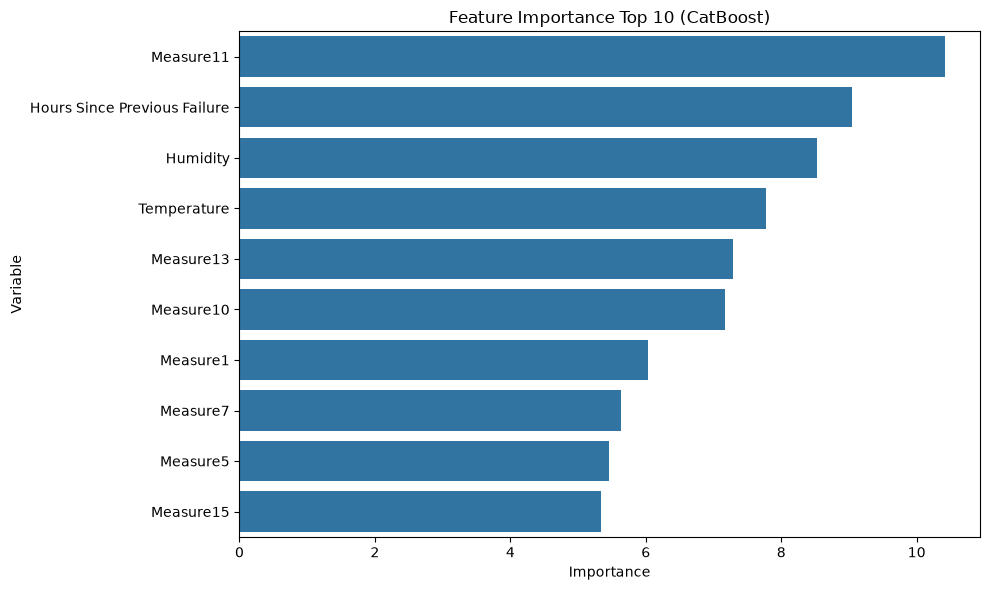

In [19]:
var_imp_cat_cls = pd.DataFrame({"Variable": Xc_train.columns, "Importance": CAT_cls.feature_importances_})
imp_top10_cat_cls = var_imp_cat_cls.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10_cat_cls)
plt.title("Feature Importance Top 10 (CatBoost)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

> CatBoost의 주요 하이퍼 파라미터:
>
> | 하이퍼파라미터 | 기본값 | 하이퍼파라미터 설명 |
> |:---:|:---:|:---:|
> | l2_leaf_reg | 3.0 | 과적합 방지를 위한 정규화 강도 |
> | random_strength | 1.0 | 트리 생성 시 랜덤성을 부여하는 정도 |
> | bagging_temperature | 1.0 | 데이터 샘플링 강도 |
> | border_count | 254 | 연속형 변수를 구간화하는 개수 |
> | iteration | 100 | 생성할 트리의 개수 |
> | depth | 6 | 트리의 최대 깊이 |
> | learning_rate | 0.1 | 각 트리가 이전 오차를 얼마나 반영할지 결정 |

In [20]:
params_cat_cls = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "l2_leaf_reg": [1, 3, 5],
    "subsample": [0.8, 1.0]
}

grid_cat_cls = GridSearchCV(
    CatBoostClassifier(random_state=0, verbose=0, bootstrap_type="Bernoulli"),
    param_grid=params_cat_cls, cv=3, scoring="f1", n_jobs=-1
)
grid_cat_cls.fit(Xc_train, Yc_train, cat_features=cat_features)

print("최적 파라미터:", grid_cat_cls.best_params_)
print("최적 F1-score (CV): %.4f" % grid_cat_cls.best_score_)

최적 파라미터: {'l2_leaf_reg': 3, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
최적 F1-score (CV): 0.8515


In [21]:
best_cat_cls_pred = grid_cat_cls.predict(Xc_test)
print("[CatBoost - 최적 모델]")
get_classscore(Yc_test, best_cat_cls_pred)

[CatBoost - 최적 모델]
Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842


---

## 2. 회귀 (Regression) - Concrete 데이터

> 분류에서 다룬 GBM 계열 모델들은 **회귀** 문제에도 동일하게 적용할 수 있음
> - Classifier → Regressor로 변경하고, 평가 지표를 MSE, R-squared 등으로 변경함
> - 각 모델의 하이퍼 파라미터는 분류와 동일하게 적용됨

### 데이터 전처리

In [22]:
Concrete = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-2_reg_data.csv"))

Y_reg = Concrete["Concrete_compressive_strength"]
X_reg = Concrete.drop(["Concrete_compressive_strength"], axis=1)

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=0)

print("학습 데이터 :", X_train_reg.shape)
print("테스트 데이터 :", X_test_reg.shape)

학습 데이터 : (721, 8)
테스트 데이터 : (309, 8)


---

### 2-1) GBM

In [23]:
GBM_reg = GradientBoostingRegressor()
GBM_reg.fit(X_train_reg, Y_train_reg)
GBM_reg_pred = GBM_reg.predict(X_test_reg)
get_regscore(Y_test_reg, GBM_reg_pred)

MSE       : 26.035
RMSE      : 5.102
MAE       : 3.830
R-squared : 0.899


#### 변수 중요도 시각화

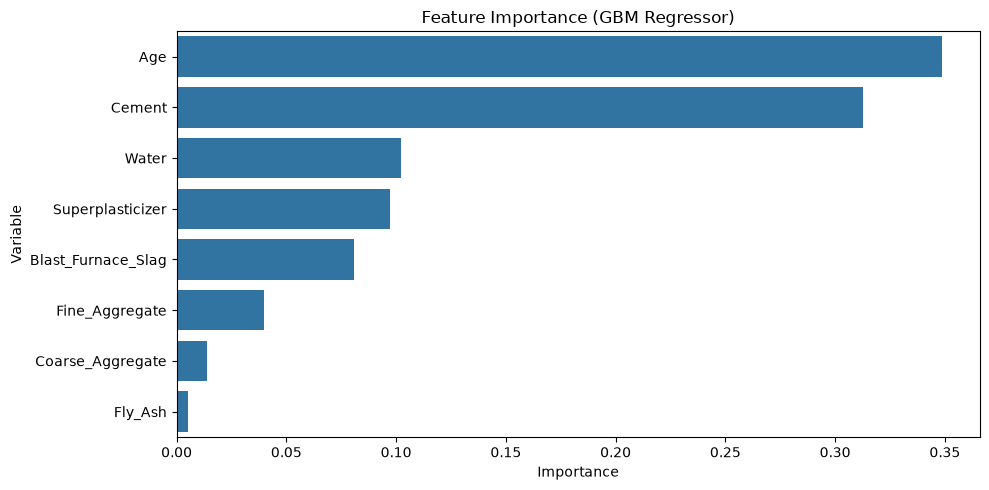

In [24]:
var_imp_gbm_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": GBM_reg.feature_importances_})
var_imp_gbm_reg = var_imp_gbm_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_gbm_reg)
plt.title("Feature Importance (GBM Regressor)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

In [25]:
params_gbm_reg = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_leaf": [1, 5],
    "subsample": [0.8, 1.0]
}

grid_gbm_reg = GridSearchCV(
    GradientBoostingRegressor(random_state=0),
    param_grid=params_gbm_reg, cv=3, scoring="r2", n_jobs=-1
)
grid_gbm_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_gbm_reg.best_params_)
print("최적 R-squared (CV): %.4f" % grid_gbm_reg.best_score_)

최적 파라미터: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 300, 'subsample': 0.8}
최적 R-squared (CV): 0.9141


In [26]:
best_gbm_reg_pred = grid_gbm_reg.predict(X_test_reg)
print("[GBM - 최적 모델]")
get_regscore(Y_test_reg, best_gbm_reg_pred)

[GBM - 최적 모델]
MSE       : 18.349
RMSE      : 4.284
MAE       : 2.803
R-squared : 0.929


---

### 2-2) XGBoost

In [27]:
XGB_reg = XGBRegressor()
XGB_reg.fit(X_train_reg, Y_train_reg)
XGB_reg_pred = XGB_reg.predict(X_test_reg)
get_regscore(Y_test_reg, XGB_reg_pred)

MSE       : 22.102
RMSE      : 4.701
MAE       : 3.161
R-squared : 0.914


#### 변수 중요도 시각화

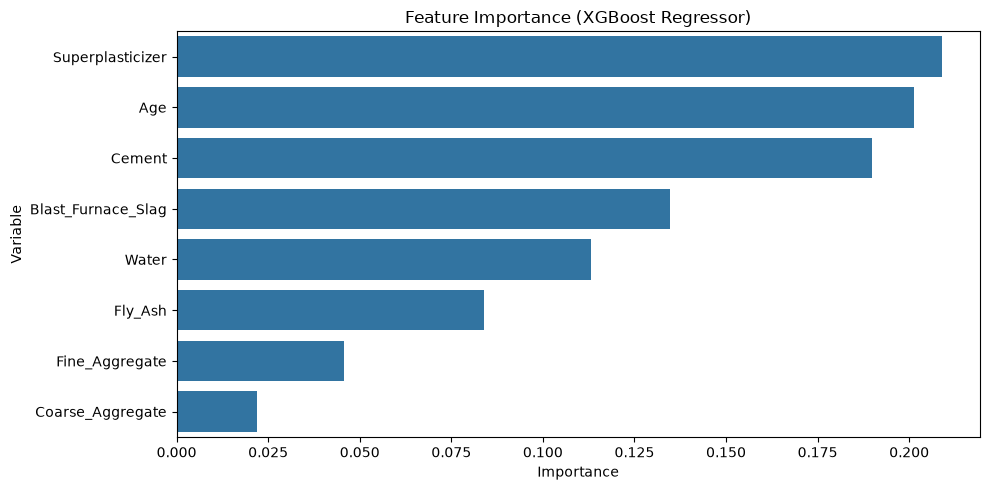

In [28]:
var_imp_xgb_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": XGB_reg.feature_importances_})
var_imp_xgb_reg = var_imp_xgb_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_xgb_reg)
plt.title("Feature Importance (XGBoost Regressor)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

In [29]:
params_xgb_reg = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "gamma": [0, 2],
    "reg_lambda": [1, 5],
    "subsample": [0.8, 1.0]
}

grid_xgb_reg = GridSearchCV(
    XGBRegressor(random_state=0),
    param_grid=params_xgb_reg, cv=3, scoring="r2", n_jobs=-1
)
grid_xgb_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_xgb_reg.best_params_)
print("최적 R-squared (CV): %.4f" % grid_xgb_reg.best_score_)

최적 파라미터: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'reg_lambda': 5, 'subsample': 0.8}
최적 R-squared (CV): 0.9136


In [30]:
best_xgb_reg_pred = grid_xgb_reg.predict(X_test_reg)
print("[XGBoost - 최적 모델]")
get_regscore(Y_test_reg, best_xgb_reg_pred)

[XGBoost - 최적 모델]
MSE       : 20.885
RMSE      : 4.570
MAE       : 3.249
R-squared : 0.919


---

### 2-3) LightGBM

In [31]:
LGBM_reg = LGBMRegressor(verbose=-1)
LGBM_reg.fit(X_train_reg, Y_train_reg)
LGBM_reg_pred = LGBM_reg.predict(X_test_reg)
get_regscore(Y_test_reg, LGBM_reg_pred)

MSE       : 21.353
RMSE      : 4.621
MAE       : 3.244
R-squared : 0.917


#### 변수 중요도 시각화

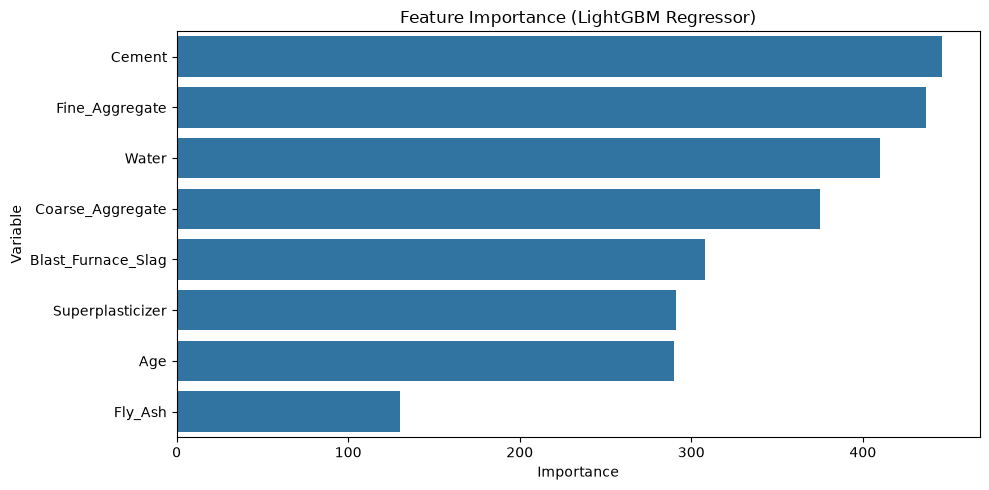

In [32]:
var_imp_lgbm_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": LGBM_reg.feature_importances_})
var_imp_lgbm_reg = var_imp_lgbm_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_lgbm_reg)
plt.title("Feature Importance (LightGBM Regressor)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

In [33]:
params_lgbm_reg = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "num_leaves": [15, 31],
    "min_child_samples": [20, 50],
    "subsample": [0.8, 1.0]
}

grid_lgbm_reg = GridSearchCV(
    LGBMRegressor(random_state=0, verbose=-1),
    param_grid=params_lgbm_reg, cv=3, scoring="r2", n_jobs=-1
)
grid_lgbm_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_lgbm_reg.best_params_)
print("최적 R-squared (CV): %.4f" % grid_lgbm_reg.best_score_)

최적 파라미터: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 15, 'subsample': 0.8}
최적 R-squared (CV): 0.9119


In [34]:
best_lgbm_reg_pred = grid_lgbm_reg.predict(X_test_reg)
print("[LightGBM - 최적 모델]")
get_regscore(Y_test_reg, best_lgbm_reg_pred)

[LightGBM - 최적 모델]
MSE       : 20.376
RMSE      : 4.514
MAE       : 3.080
R-squared : 0.921


---

### 2-4) CatBoost

In [35]:
CAT_reg = CatBoostRegressor(verbose=0)
# 해당 데이터셋에는 범주형이 없어서 따로 cat_features를 지정하지 않아도 동작 가능
CAT_reg.fit(X_train_reg, Y_train_reg)
CAT_reg_pred = CAT_reg.predict(X_test_reg)
get_regscore(Y_test_reg, CAT_reg_pred)

MSE       : 17.915
RMSE      : 4.233
MAE       : 2.778
R-squared : 0.930


#### 변수 중요도 시각화

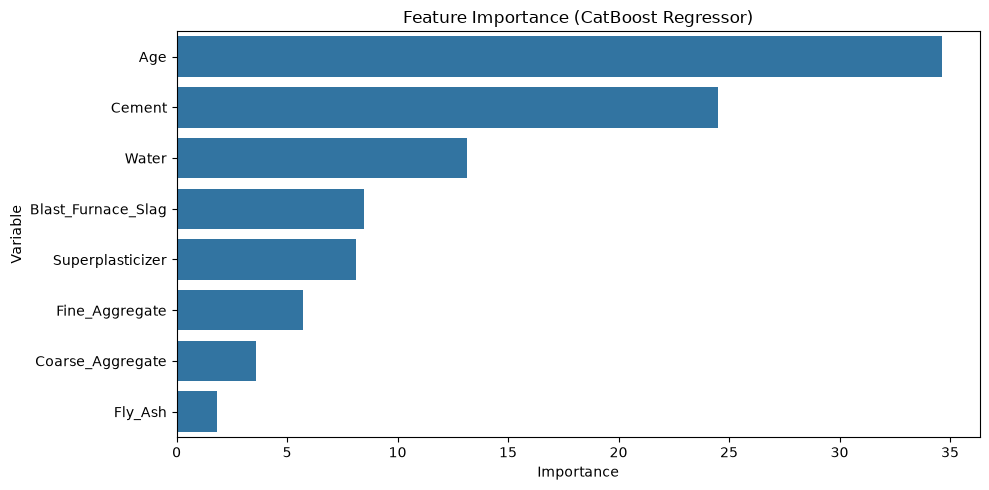

In [36]:
var_imp_cat_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": CAT_reg.feature_importances_})
var_imp_cat_reg = var_imp_cat_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_cat_reg)
plt.title("Feature Importance (CatBoost Regressor)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

In [37]:
params_cat_reg = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "l2_leaf_reg": [1, 3, 5]
}

grid_cat_reg = GridSearchCV(
    CatBoostRegressor(random_state=0, verbose=0),
    param_grid=params_cat_reg, cv=3, scoring="r2"
)
grid_cat_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_cat_reg.best_params_)
print("최적 R-squared (CV): %.4f" % grid_cat_reg.best_score_)

최적 파라미터: {'l2_leaf_reg': 3, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
최적 R-squared (CV): 0.9242


In [38]:
best_cat_reg_pred = grid_cat_reg.predict(X_test_reg)
print("[CatBoost - 최적 모델]")
get_regscore(Y_test_reg, best_cat_reg_pred)

[CatBoost - 최적 모델]
MSE       : 20.723
RMSE      : 4.552
MAE       : 3.117
R-squared : 0.919


---

In [39]:
best_models_cls = {
    "GBM": best_gbm_cls_pred,
    "XGBoost": best_xgb_cls_pred,
    "LightGBM": best_lgbm_cls_pred,
    "CatBoost": best_cat_cls_pred
}

best_results_cls = []
for name, pred in best_models_cls.items():
    true = Yc_test if name == "CatBoost" else Y_test
    best_results_cls.append({
        "Model": name,
        "Accuracy": round(accuracy_score(true, pred), 3),
        "Precision": round(precision_score(true, pred), 3),
        "Recall": round(recall_score(true, pred), 3),
        "F1-score": round(f1_score(true, pred), 3)
    })

pd.DataFrame(best_results_cls)

,Model,Accuracy,Precision,Recall,F1-score
0,GBM,0.997,0.944,0.773,0.850
1,XGBoost,0.997,1.000,0.727,0.842
2,LightGBM,0.997,0.941,0.727,0.821
3,CatBoost,0.997,1.000,0.727,0.842


In [40]:
best_models_reg = {
    "GBM": best_gbm_reg_pred,
    "XGBoost": best_xgb_reg_pred,
    "LightGBM": best_lgbm_reg_pred,
    "CatBoost": best_cat_reg_pred
}

best_results_reg = []
for name, pred in best_models_reg.items():
    best_results_reg.append({
        "Model": name,
        "RMSE": round(np.sqrt(mean_squared_error(Y_test_reg, pred)), 3),
        "MAE": round(mean_absolute_error(Y_test_reg, pred), 3),
        "R-squared": round(r2_score(Y_test_reg, pred), 3)
    })

pd.DataFrame(best_results_reg)

,Model,RMSE,MAE,R-squared
0,GBM,4.284,2.803,0.929
1,XGBoost,4.570,3.249,0.919
2,LightGBM,4.514,3.080,0.921
3,CatBoost,4.552,3.117,0.919


---

## 3. Vibe Coding 실습

**[과제 1]** 지수는 LightGBM이 XGBoost보다 빠르게 학습된다는 설명을 들었지만, 실제로 얼마나 차이가 나는지 궁금했습니다. AI와 상의하여 동일한 데이터셋(회귀 또는 분류)으로 XGBoost와 LightGBM을 학습시키고 학습 시간과 예측 성능을 비교해 보세요.

In [42]:
# [과제 1] XGBoost vs LightGBM 학습 시간 및 예측 성능 비교
# 동일 데이터셋: MachineFailure 분류 (X_train, Y_train, X_test, Y_test)

# 공통 하이퍼파라미터 (공정한 비교를 위해 동일 조건 설정)
common_params = {
    "n_estimators": 300,
    "learning_rate": 0.01,
    "max_depth": 5,
    "subsample": 0.8,
    "random_state": 0,
}

n_runs = 5  # 학습 시간 변동을 줄이기 위해 여러 번 측정 후 평균

def measure_train_time(model, X, y, n_runs=5):
    times = []
    for _ in range(n_runs):
        m = model.__class__(**model.get_params())
        start = time.perf_counter()
        m.fit(X, y)
        times.append(time.perf_counter() - start)
    return np.mean(times), m  # 마지막 학습 모델 반환

# XGBoost
xgb_model = XGBClassifier(**common_params, eval_metric="logloss")
xgb_time, xgb_fitted = measure_train_time(xgb_model, X_train, Y_train, n_runs)
xgb_pred = xgb_fitted.predict(X_test)

# LightGBM
lgbm_model = LGBMClassifier(**common_params, subsample_freq=1, verbose=-1)
lgbm_time, lgbm_fitted = measure_train_time(lgbm_model, X_train, Y_train, n_runs)
lgbm_pred = lgbm_fitted.predict(X_test)

# 비교 표 생성
comparison_df = pd.DataFrame([
    {
        "Model": "XGBoost",
        "Train Time (sec)": round(xgb_time, 4),
        "Accuracy": round(accuracy_score(Y_test, xgb_pred), 3),
        "Precision": round(precision_score(Y_test, xgb_pred), 3),
        "Recall": round(recall_score(Y_test, xgb_pred), 3),
        "F1-score": round(f1_score(Y_test, xgb_pred), 3),
    },
    {
        "Model": "LightGBM",
        "Train Time (sec)": round(lgbm_time, 4),
        "Accuracy": round(accuracy_score(Y_test, lgbm_pred), 3),
        "Precision": round(precision_score(Y_test, lgbm_pred), 3),
        "Recall": round(recall_score(Y_test, lgbm_pred), 3),
        "F1-score": round(f1_score(Y_test, lgbm_pred), 3),
    },
])

speed_ratio = xgb_time / lgbm_time
print(f"학습 데이터: {X_train.shape}, 테스트 데이터: {X_test.shape}")
print(f"공통 하이퍼파라미터: {common_params}")
print(f"학습 시간 측정 횟수: {n_runs}회 평균\n")
print(f"LightGBM이 XGBoost보다 약 {speed_ratio:.2f}배 빠릅니다.\n")
comparison_df

학습 데이터: (5530, 31), 테스트 데이터: (2370, 31)
공통 하이퍼파라미터: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 5, 'subsample': 0.8, 'random_state': 0}
학습 시간 측정 횟수: 5회 평균

LightGBM이 XGBoost보다 약 2.95배 빠릅니다.



,Model,Train Time (sec),Accuracy,Precision,Recall,F1-score
0,XGBoost,3.1578,0.997,1.0,0.727,0.842
1,LightGBM,1.0715,0.997,1.0,0.727,0.842


**[과제 2]** 지수는 GBM, XGBoost, LightGBM, CatBoost가 같은 데이터를 학습했지만, 각 모델이 중요하게 판단하는 변수는 다를 수 있다고 생각했습니다. AI와 함께 회귀 또는 분류 문제에서 네 모델의 변수 중요도를 한눈에 비교할 수 있는 시각화 방법을 상의하고, 실제로 비교하여 모델 간 중요도 순위가 얼마나 일치하는지 확인해 보세요.


[GBM] 변수 중요도 Top 10


,Rank,Variable,Importance
0,1,Humidity,0.612103
1,2,Temperature,0.131572
2,3,Hours Since Previous Failure,0.062037
3,4,Measure10,0.026024
4,5,Measure14,0.025954
5,6,Measure11,0.021208
6,7,Measure6,0.017506
7,8,Measure8,0.014089
8,9,Measure15,0.011058
9,10,Measure4,0.010846



[XGBoost] 변수 중요도 Top 10


,Rank,Variable,Importance
0,1,Temperature,0.232790
1,2,Humidity,0.201854
2,3,Hours Since Previous Failure,0.130879
3,4,Measure10,0.038458
4,5,Measure11,0.028873
5,6,Measure1,0.027724
6,7,Measure3_2,0.026667
7,8,Measure12,0.026362
8,9,Operator_Operator3,0.024702
9,10,Measure2_2,0.023963



[LightGBM] 변수 중요도 Top 10


,Rank,Variable,Importance
0,1,Hours Since Previous Failure,924
1,2,Temperature,645
2,3,Humidity,602
3,4,Measure8,332
4,5,Measure11,289
5,6,Measure14,242
6,7,Measure10,229
7,8,Measure7,201
8,9,Measure1,176
9,10,Measure4,161



[CatBoost] 변수 중요도 Top 10


,Rank,Variable,Importance
0,1,Humidity,14.654137
1,2,Temperature,12.654083
2,3,Hours Since Previous Failure,11.373985
3,4,Measure1,6.761817
4,5,Measure11,6.580527
5,6,Measure15,4.419619
6,7,Measure10,4.248231
7,8,Measure8,4.152272
8,9,Measure14,3.926352
9,10,Measure5,3.819815


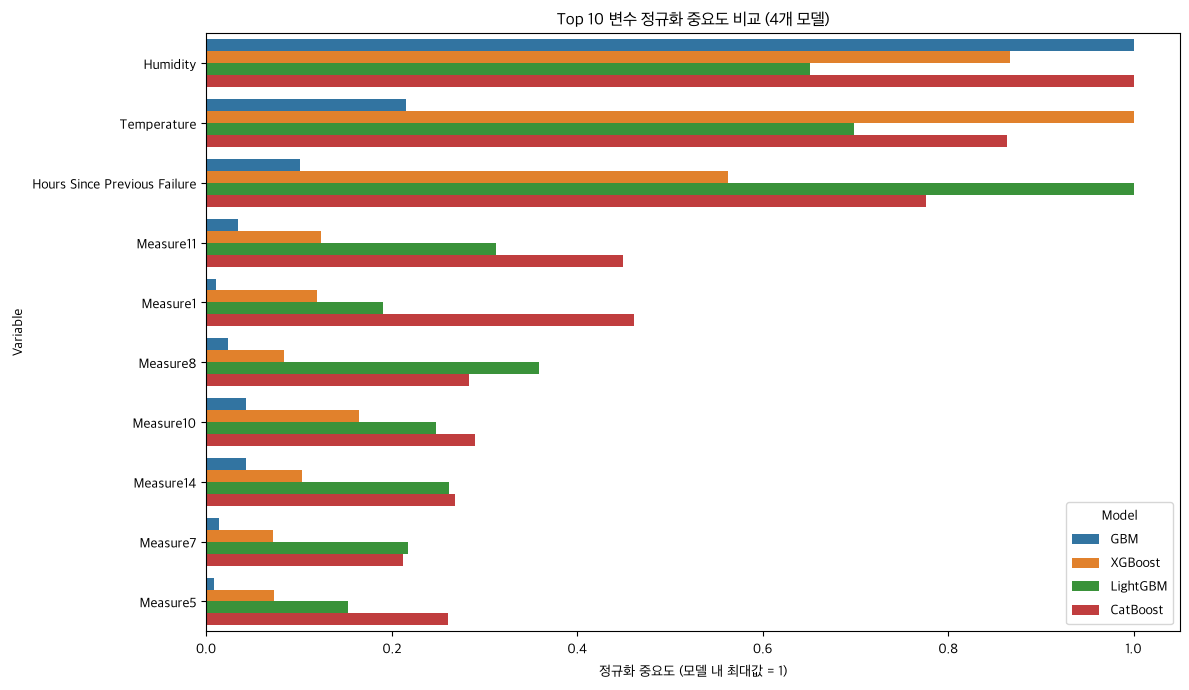

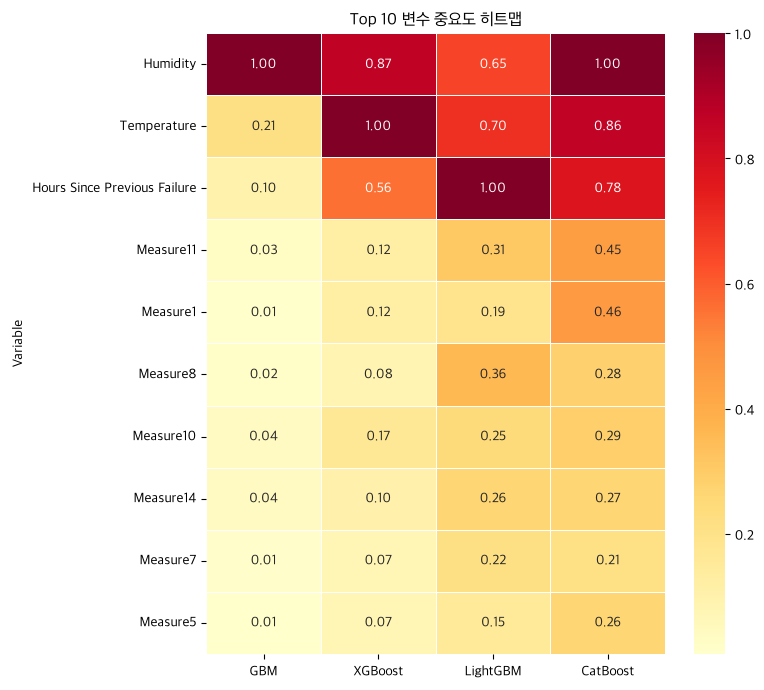

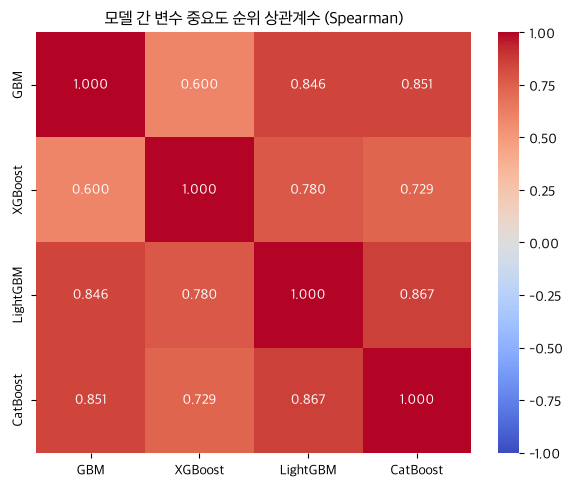


[전체 변수 Spearman 순위 상관계수]


,GBM,XGBoost,LightGBM,CatBoost
GBM,1.000,0.600,0.846,0.851
XGBoost,0.600,1.000,0.780,0.729
LightGBM,0.846,0.780,1.000,0.867
CatBoost,0.851,0.729,0.867,1.000



[Top 10 변수 Spearman 순위 상관계수]


,Model A,Model B,Spearman (Top10)
0,GBM,XGBoost,0.867
1,GBM,LightGBM,0.830
2,GBM,CatBoost,0.733
3,XGBoost,LightGBM,0.721
4,XGBoost,CatBoost,0.927
5,LightGBM,CatBoost,0.685



모델 쌍 평균 Spearman 상관계수 (전체 변수): 0.779

=== 해석 ===
Spearman 상관계수는 1에 가까울수록 변수 중요도 '순위'가 모델 간에 비슷함을 의미합니다.
- 평균 0.779으로, 핵심 변수는 어느 정도 공통이지만 모델별 세부 순위 차이가 있습니다.

4개 모델 모두 Top 5에 포함된 공통 변수: ['Hours Since Previous Failure', 'Humidity', 'Temperature']


In [45]:
# [과제 2] 4개 부스팅 모델 변수 중요도 비교 (MachineFailure 분류 데이터)
from scipy.stats import spearmanr

# 1) 동일 데이터셋(X_train, Y_train)으로 4개 모델 학습
common_params = {
    "n_estimators": 300,
    "learning_rate": 0.01,
    "max_depth": 5,
    "subsample": 0.8,
    "random_state": 0,
}

models = {
    "GBM": GradientBoostingClassifier(**common_params),
    "XGBoost": XGBClassifier(**common_params, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(**common_params, subsample_freq=1, verbose=-1),
    "CatBoost": CatBoostClassifier(**common_params, verbose=0),
}

importance_dict = {}
for name, model in models.items():
    model.fit(X_train, Y_train)
    imp_df = (
        pd.DataFrame({"Variable": X_train.columns, "Importance": model.feature_importances_})
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )
    imp_df["Rank"] = np.arange(1, len(imp_df) + 1)
    importance_dict[name] = imp_df

# 2) 모델별 변수 중요도 정렬 결과 (Top 10)
for name, imp_df in importance_dict.items():
    print(f"\n[{name}] 변수 중요도 Top 10")
    display(imp_df.head(10)[["Rank", "Variable", "Importance"]])

# 3) 모델 간 비교 시각화
top_n = 10

# 중요도를 0~1로 정규화한 뒤, 모델 평균 상위 변수 선정
norm_imp = pd.DataFrame(index=X_train.columns)
for name, imp_df in importance_dict.items():
    s = imp_df.set_index("Variable")["Importance"]
    norm_imp[name] = s / s.max()

top_vars = norm_imp.mean(axis=1).sort_values(ascending=False).head(top_n).index.tolist()
plot_df = norm_imp.loc[top_vars].reset_index().melt(id_vars="index", var_name="Model", value_name="Norm Importance")
plot_df = plot_df.rename(columns={"index": "Variable"})

# (1) 그룹 막대그래프: 모델별 Top 변수 중요도 나란히 비교
plt.figure(figsize=(12, 7))
sns.barplot(data=plot_df, x="Norm Importance", y="Variable", hue="Model", orient="h")
plt.title(f"Top {top_n} 변수 정규화 중요도 비교 (4개 모델)")
plt.xlabel("정규화 중요도 (모델 내 최대값 = 1)")
plt.tight_layout()
plt.show()

# (2) 히트맵: 변수 × 모델 중요도 한눈에 비교
heatmap_df = norm_imp.loc[top_vars]
plt.figure(figsize=(8, 7))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title(f"Top {top_n} 변수 중요도 히트맵")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# 4) 모델 간 변수 중요도 순위 일치도 분석
rank_df = pd.DataFrame(index=X_train.columns)
for name, imp_df in importance_dict.items():
    rank_df[name] = imp_df.set_index("Variable")["Rank"]

# 전체 변수 기준 Spearman 순위 상관계수
model_names = list(models.keys())
corr_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
for m1 in model_names:
    for m2 in model_names:
        corr_matrix.loc[m1, m2] = spearmanr(rank_df[m1], rank_df[m2]).correlation

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix.astype(float), annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("모델 간 변수 중요도 순위 상관계수 (Spearman)")
plt.tight_layout()
plt.show()

# Top 10 변수만 대상으로 한 순위 일치도
top_rank_df = rank_df.loc[top_vars]
top_pair_corr = []
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        m1, m2 = model_names[i], model_names[j]
        rho = spearmanr(top_rank_df[m1], top_rank_df[m2]).correlation
        top_pair_corr.append({"Model A": m1, "Model B": m2, "Spearman (Top10)": round(rho, 3)})

top_corr_table = pd.DataFrame(top_pair_corr)
avg_corr = corr_matrix.values[np.triu_indices(len(model_names), k=1)].mean()

print("\n[전체 변수 Spearman 순위 상관계수]")
display(corr_matrix.round(3))
print("\n[Top 10 변수 Spearman 순위 상관계수]")
display(top_corr_table)
print(f"\n모델 쌍 평균 Spearman 상관계수 (전체 변수): {avg_corr:.3f}")

print("\n=== 해석 ===")
print("Spearman 상관계수는 1에 가까울수록 변수 중요도 '순위'가 모델 간에 비슷함을 의미합니다.")
if avg_corr >= 0.8:
    print(f"- 평균 {avg_corr:.3f}으로, 4개 모델이 중요 변수 순위에서 높은 일치를 보입니다.")
elif avg_corr >= 0.5:
    print(f"- 평균 {avg_corr:.3f}으로, 핵심 변수는 어느 정도 공통이지만 모델별 세부 순위 차이가 있습니다.")
else:
    print(f"- 평균 {avg_corr:.3f}으로, 모델마다 중요하게 보는 변수 순위가 꽤 다릅니다.")

# 공통 Top 5 변수 확인
common_top5 = set(importance_dict["GBM"].head(5)["Variable"])
for name in model_names[1:]:
    common_top5 &= set(importance_dict[name].head(5)["Variable"])
print(f"\n4개 모델 모두 Top 5에 포함된 공통 변수: {sorted(common_top5) if common_top5 else '없음'}")

In [46]:
# 핵심 변수 비교 표: 상관계수 + 모델별 중요도/순위
# (바로 위 셀에서 학습한 importance_dict, X_train, Y_train 사용)
key_vars = ["Humidity", "Temperature", "Hours Since Previous Failure"]

key_corr = pd.DataFrame(index=key_vars, columns=key_vars + ["Failure"])
for v in key_vars:
    key_corr.loc[v, "Failure"] = X_train[v].corr(Y_train)
    for v2 in key_vars:
        key_corr.loc[v, v2] = X_train[v].corr(X_train[v2])
key_corr = key_corr.astype(float).round(3)

key_imp_rows = []
for name, imp_df in importance_dict.items():
    for v in key_vars:
        row = imp_df[imp_df["Variable"] == v].iloc[0]
        key_imp_rows.append({
            "Model": name,
            "Variable": v,
            "Importance": round(row["Importance"], 4),
            "Rank": int(row["Rank"]),
        })
key_imp_table = pd.DataFrame(key_imp_rows)
key_imp_pivot = key_imp_table.pivot(index="Variable", columns="Model", values="Importance")
key_rank_pivot = key_imp_table.pivot(index="Variable", columns="Model", values="Rank")

print("[핵심 변수 상관계수 (학습 데이터)]")
display(key_corr)
print("\n[핵심 변수 모델별 Raw Importance]")
display(key_imp_pivot)
print("\n[핵심 변수 모델별 순위]")
display(key_rank_pivot.astype(int))

[핵심 변수 상관계수 (학습 데이터)]


,Humidity,Temperature,Hours Since Previous Failure,Failure
Humidity,1.000,-0.053,0.044,-0.197
Temperature,-0.053,1.000,-0.014,0.218
Hours Since Previous Failure,0.044,-0.014,1.000,-0.076



[핵심 변수 모델별 Raw Importance]


Model,CatBoost,GBM,LightGBM,XGBoost
Variable,,,,
Hours Since Previous Failure,11.3740,0.0620,924.0,0.1309
Humidity,14.6541,0.6121,602.0,0.2019
Temperature,12.6541,0.1316,645.0,0.2328



[핵심 변수 모델별 순위]


Model,CatBoost,GBM,LightGBM,XGBoost
Variable,,,,
Hours Since Previous Failure,3,3,1,3
Humidity,1,1,3,2
Temperature,2,2,2,1


**[과제 3]** 지수는 여러 머신러닝 모델의 예측 결과를 결합하는 Stacking Ensemble이라는 방법을 알게 되었고, Stacking 모델이 단일 앙상블 모델보다 항상 더 좋은 성능을 보이는지 궁금해졌습니다. AI와 상의하여 결합할 모델들을 선택해 Stacking 모델을 구축해 보세요. 이후 Stacking 모델과 각 단일 앙상블 모델의 성능을 비교해 보세요.

학습 데이터: (5530, 31) | 테스트 데이터: (2370, 31)


,Accuracy,Precision,Recall,F1-score
Model,,,,
GBM,0.998,1.0,0.773,0.872
XGBoost,0.997,1.0,0.727,0.842
LightGBM,0.997,1.0,0.727,0.842
CatBoost,0.997,1.0,0.727,0.842
Stacking,0.997,1.0,0.727,0.842


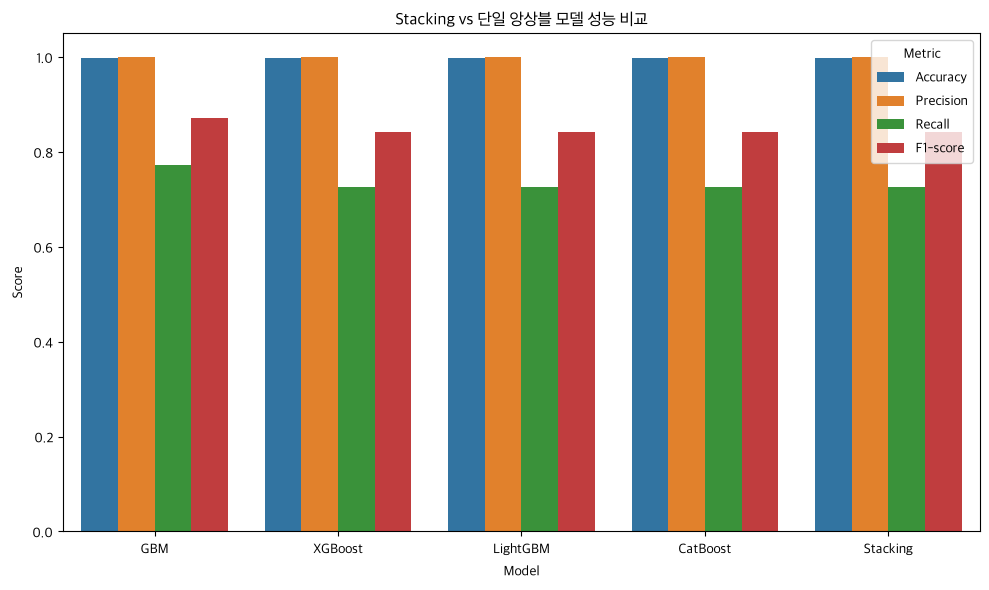


F1-score 최고 모델: GBM (0.872)
Stacking F1-score (0.842) < 최고 단일 모델 GBM (0.872)
→ Stacking이 항상 더 좋은 것은 아니며, 데이터·모델 조합에 따라 달라질 수 있습니다.


In [48]:
# [과제 3] Stacking Ensemble vs 단일 앙상블 모델 성능 비교 (MachineFailure 분류)
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

common_params = {
    "n_estimators": 300,
    "learning_rate": 0.01,
    "max_depth": 5,
    "subsample": 0.8,
    "random_state": 0,
}

base_models = [
    ("GBM", GradientBoostingClassifier(**common_params)),
    ("XGBoost", XGBClassifier(**common_params, eval_metric="logloss")),
    ("LightGBM", LGBMClassifier(**common_params, subsample_freq=1, verbose=-1)),
    ("CatBoost", CatBoostClassifier(**common_params, verbose=0)),
]

# 1) 단일 앙상블 모델 학습 및 평가
results = []
for name, model in base_models:
    model.fit(X_train, Y_train)
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(Y_test, pred), 3),
        "Precision": round(precision_score(Y_test, pred), 3),
        "Recall": round(recall_score(Y_test, pred), 3),
        "F1-score": round(f1_score(Y_test, pred), 3),
    })

# 2) Stacking Ensemble (메타 학습기: Logistic Regression)
stacking_clf = StackingClassifier(
    estimators=[
        ("GBM", GradientBoostingClassifier(**common_params)),
        ("XGBoost", XGBClassifier(**common_params, eval_metric="logloss")),
        ("LightGBM", LGBMClassifier(**common_params, subsample_freq=1, verbose=-1)),
        ("CatBoost", CatBoostClassifier(**common_params, verbose=0)),
    ],
    final_estimator=LogisticRegression(random_state=0, max_iter=1000),
    cv=3,
    n_jobs=-1,
)
stacking_clf.fit(X_train, Y_train)
stack_pred = stacking_clf.predict(X_test)
results.append({
    "Model": "Stacking",
    "Accuracy": round(accuracy_score(Y_test, stack_pred), 3),
    "Precision": round(precision_score(Y_test, stack_pred), 3),
    "Recall": round(recall_score(Y_test, stack_pred), 3),
    "F1-score": round(f1_score(Y_test, stack_pred), 3),
})

# 3) 성능 비교 표
compare_df = pd.DataFrame(results).set_index("Model")
print("학습 데이터:", X_train.shape, "| 테스트 데이터:", X_test.shape)
display(compare_df)

# 4) 성능 비교 그래프
plot_metrics = compare_df.reset_index().melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_metrics, x="Model", y="Score", hue="Metric")
plt.title("Stacking vs 단일 앙상블 모델 성능 비교")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.tight_layout()
plt.show()

# F1-score 기준 최고 모델
best_model = compare_df["F1-score"].idxmax()
best_f1 = compare_df["F1-score"].max()
stack_f1 = compare_df.loc["Stacking", "F1-score"]

print(f"\nF1-score 최고 모델: {best_model} ({best_f1:.3f})")
best_single_f1 = compare_df.drop("Stacking")["F1-score"].max()
best_single_name = compare_df.drop("Stacking")["F1-score"].idxmax()
if stack_f1 >= best_single_f1:
    print(f"Stacking F1-score ({stack_f1:.3f})이 단일 모델 중 최고 성능 이상입니다.")
else:
    print(f"Stacking F1-score ({stack_f1:.3f}) < 최고 단일 모델 {best_single_name} ({best_single_f1:.3f})")
    print("→ Stacking이 항상 더 좋은 것은 아니며, 데이터·모델 조합에 따라 달라질 수 있습니다.")